In [9]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import osmnx as ox
import contextily as cx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import osmnx as ox
import folium

In [2]:
def load_graph(pkl_path: Path):
    with pkl_path.open("rb") as f:
        G = pickle.load(f)
    return G

def compute_graph_centroid(gdf_nodes):
    if gdf_nodes.crs != "EPSG:4326":
        gdf = gdf_nodes.to_crs(epsg=4326)
    else:
        gdf = gdf_nodes

    lon = gdf.geometry.x.mean()
    lat = gdf.geometry.y.mean()

    return lon, lat


def plot_graph_on_osm(G, label=""):
    try:
        gdf_nodes, gdf_edges = ox.graph_to_gdfs(
            G,
            nodes=True,
            edges=True,
            node_geometry=True,
            fill_edge_geometry=True
        )
    except Exception as e:
        raise e

    if gdf_nodes.crs is None:
        gdf_nodes = gdf_nodes.set_crs(epsg=4326)
        gdf_edges = gdf_edges.set_crs(epsg=4326)

    lon_c, lat_c = compute_graph_centroid(gdf_nodes)
    print(f"Centroid: lon={lon_c:.6f}, lat={lat_c:.6f}")

    gdf_nodes_3857 = gdf_nodes.to_crs(epsg=3857)
    gdf_edges_3857 = gdf_edges.to_crs(epsg=3857)

    import geopandas as gpd
    from shapely.geometry import Point

    centroid_3857 = gpd.GeoSeries(
        [Point(lon_c, lat_c)], crs="EPSG:4326"
    ).to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(12, 9))

    gdf_nodes_3857.plot(ax=ax, markersize=1, color="red", label=f"Type ({label})")

    centroid_3857.plot(
        ax=ax,
        markersize=200,
        color="blue",
        marker="*",
        label="Centroid"
    )

    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

    ax.set_axis_off()

    xmin, ymin, xmax, ymax = gdf_edges_3857.total_bounds
    pad_x = (xmax - xmin) * 0.03
    pad_y = (ymax - ymin) * 0.03
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.legend()

    plt.tight_layout()
    plt.show()


In [3]:
def analyze_centroid_shifts(graph_paths: dict, original_key: str = "original") -> pd.DataFrame:
    rows = []

    for name, pkl_path in graph_paths.items():
        G = load_graph(Path(pkl_path))
        gdf_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False, node_geometry=True)

        if gdf_nodes.crs is None:
            gdf_nodes = gdf_nodes.set_crs(epsg=4326)

        lon, lat = compute_graph_centroid(gdf_nodes)

        pt_3857 = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326").to_crs(epsg=3857).iloc[0]
        rows.append({
            "name": name,
            "path": str(pkl_path),
            "lon": lon,
            "lat": lat,
            "x_3857_m": pt_3857.x,
            "y_3857_m": pt_3857.y
        })

    dfc = pd.DataFrame(rows).set_index("name")

    if original_key not in dfc.index:
        raise ValueError(f"original_key='{original_key}' non trovato tra: {list(dfc.index)}")

    x0 = dfc.loc[original_key, "x_3857_m"]
    y0 = dfc.loc[original_key, "y_3857_m"]

    dfc["dx_m"] = dfc["x_3857_m"] - x0
    dfc["dy_m"] = dfc["y_3857_m"] - y0
    dfc["dist_m"] = (dfc["dx_m"]**2 + dfc["dy_m"]**2) ** 0.5

    print("\n=== Centroid shifts vs original (meters, EPSG:3857) ===")
    print(dfc[["lon", "lat", "dx_m", "dy_m", "dist_m"]].sort_values("dist_m"))

    return dfc.reset_index()


In [4]:
def plot_centroids_on_osm(centroids_df: pd.DataFrame, original_key: str = "original"):
    gdf = gpd.GeoDataFrame(
        centroids_df.copy(),
        geometry=gpd.points_from_xy(centroids_df["lon"], centroids_df["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(12, 9))

    gdf_other = gdf[gdf["name"] != original_key]
    gdf_orig = gdf[gdf["name"] == original_key]

    if not gdf_other.empty:
        gdf_other.plot(ax=ax, markersize=80, alpha=0.9)

    if not gdf_orig.empty:
        gdf_orig.plot(ax=ax, markersize=250, marker="*", color="red", label="original")

    for _, r in gdf.iterrows():
        label = r["name"]
        if r["name"] != original_key:
            label = f'{r["name"]} ({r["dist_m"]:.0f} m)'
        ax.annotate(label, (r.geometry.x, r.geometry.y), xytext=(6, 6), textcoords="offset points", fontsize=10)

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=13)
    ax.set_axis_off()

    xmin, ymin, xmax, ymax = gdf.total_bounds
    pad_x = (xmax - xmin) * 0.2 if xmax > xmin else 200
    pad_y = (ymax - ymin) * 0.2 if ymax > ymin else 200
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    plt.tight_layout()
    plt.show()


In [10]:
def folium_centroids_map(
    centroids_df: pd.DataFrame,
    original_key: str = "original",
    tiles: str = "CartoDB positron",
    out_html: Path | None = None,
):
    if (centroids_df["name"] == original_key).any():
        row0 = centroids_df.loc[centroids_df["name"] == original_key].iloc[0]
        center = [row0["lat"], row0["lon"]]
    else:
        center = [centroids_df["lat"].mean(), centroids_df["lon"].mean()]

    m = folium.Map(location=center, tiles=tiles, zoom_start=13, control_scale=True)

    for _, r in centroids_df.iterrows():
        name = r["name"]
        lat = float(r["lat"])
        lon = float(r["lon"])

        if name == original_key:
            popup = folium.Popup(f"<b>{name}</b>", max_width=250)
            folium.Marker(
                location=[lat, lon],
                popup=popup,
                tooltip=name,
                icon=folium.Icon(color="red", icon="star", prefix="fa"),  # richiede FontAwesome (folium lo include)
            ).add_to(m)
        else:
            dist = r["dist_m"] if "dist_m" in centroids_df.columns else None
            dist_txt = f"{dist:.0f} m" if dist is not None else "n/a"
            popup = folium.Popup(f"<b>{name}</b><br>dist: {dist_txt}", max_width=250)

            folium.CircleMarker(
                location=[lat, lon],
                radius=6,
                color="#1f77b4",
                fill=True,
                fill_opacity=0.9,
                popup=popup,
                tooltip=f"{name} ({dist_txt})",
            ).add_to(m)

    bounds = centroids_df[["lat", "lon"]].values.tolist()
    m.fit_bounds(bounds, padding=(30, 30))

    if out_html is not None:
        out_html = Path(out_html)
        out_html.parent.mkdir(parents=True, exist_ok=True)
        m.save(str(out_html))
        print(f"Folium map saved: {out_html}")

    return m


In [5]:
def analyze_stats(graph_stats_file: str):
    df_stats = pd.read_csv(graph_stats_file)
    df_stats["gravitational_work"] = df_stats["work_wd"] + df_stats["work_hol"]

    original_work = df_stats[df_stats["variant"] == "original"]["gravitational_work"].iloc[0]
    better_variants = df_stats[df_stats["gravitational_work"] < original_work]
    better_variants['pct_improvement'] = 100 * (better_variants["gravitational_work"] - original_work ) / original_work
    print(f"\n=== Variants with less gravitational work than original {original_work} ===")
    print(better_variants[["variant", "gravitational_work", "pct_improvement"]].sort_values("gravitational_work")) 

/tmp/ipykernel_880168/485207595.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  better_variants['pct_improvement'] = 100 * (better_variants["gravitational_work"] - original_work ) / original_work



=== Variants with less gravitational work than original 261332839.0 ===
         variant  gravitational_work  pct_improvement
1   translated_1         225140596.0       -13.849099
2   translated_2         227194969.0       -13.062985
3   translated_3         249064952.0        -4.694353
37   scale_y_0.5         249399638.0        -4.566285
5   translated_5         255922067.0        -2.070452
36   scale_x_0.5         258793802.0        -0.971572
7   translated_7         260291024.0        -0.398654

=== Centroid shifts vs original (meters, EPSG:3857) ===
               lon        lat          dx_m          dy_m        dist_m
name                                                                   
original -3.824163  40.423773      0.000000      0.000000      0.000000
T5       -3.824163  40.373773      0.000000  -7308.724343   7308.724343
T4       -3.924163  40.373773 -11131.949079  -7308.724343  13316.821761
T2       -3.824163  40.323773      0.000000 -14612.027568  14612.027568
T3    

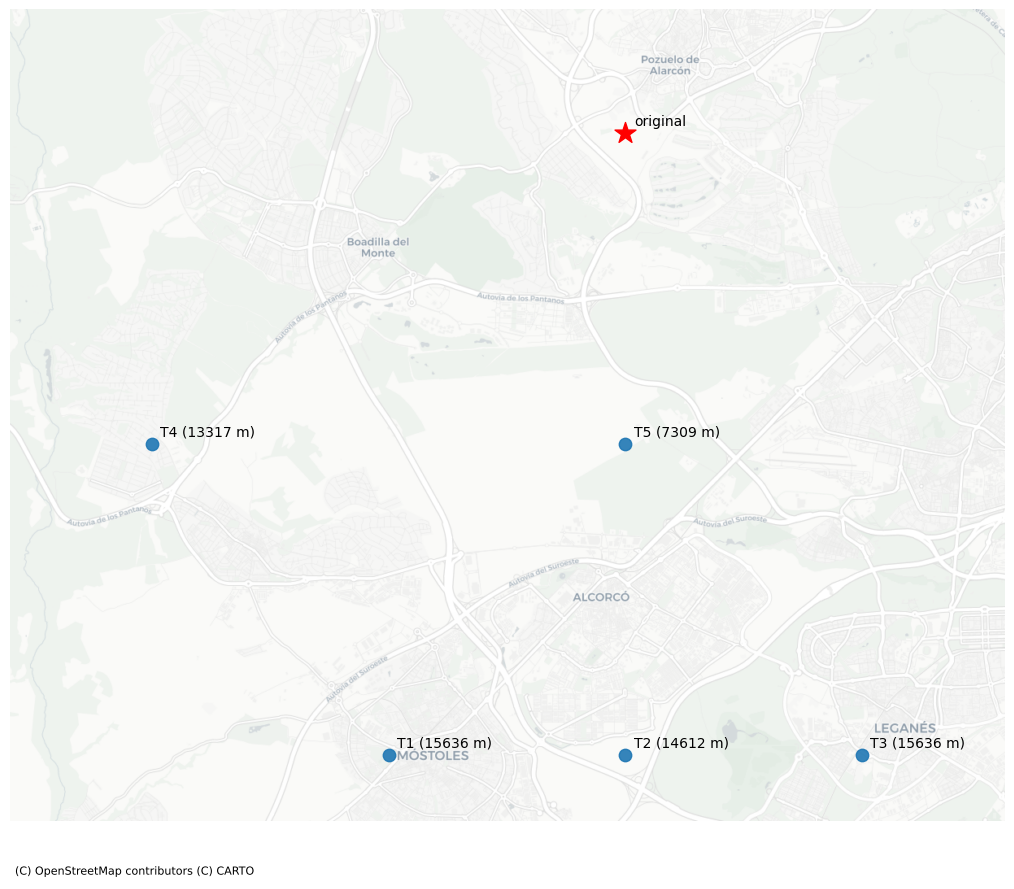

Folium map saved: centroids_map.html


In [11]:
def main():
    graph_paths = {
        "original": "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/graph_original.pkl",
        "T1": "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/graph_translated_1.pkl",
        "T2": "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/graph_translated_2.pkl",
        "T3": "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/graph_translated_3.pkl",
        "T4": "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/graph_translated_5.pkl",
        "T5": "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/graph_translated_7.pkl",
    }
    
    graph_stats_file = "/home/fbellisardi/code/topolity/data/data_processed/madrid/graphs/gravitational_work_by_variant.csv"
    analyze_stats(graph_stats_file)

    dfc = analyze_centroid_shifts(graph_paths, original_key="original")
    plot_centroids_on_osm(dfc, original_key="original")

    m = folium_centroids_map(dfc, original_key="original", out_html=Path("centroids_map.html"))
    m

    # for name, p in graph_paths.items():
    #     print("\n---", name, "---")
    #     plot_graph_on_osm(load_graph(Path(p)))




if __name__ == "__main__":
    main()
